In [1]:
pip install dataretrieval

  Using cached dataretrieval-1.1.2-py3-none-any.whl.metadata (13 kB)
Using cached dataretrieval-1.1.2-py3-none-any.whl (62 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
# run pip install dataretrieval in terminal before running
# import some regular packages
import os
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray
import pyproj

# import package that helps with retrieving data from usgs stream gauges
import dataretrieval.nwis as nwis

In [3]:
# nwis.get_record() pulled from AI. Adapted to be a callable function by me.
# all inputs are strings

def usgs_discharge(station, start_date, end_date):
    df = nwis.get_record(
        sites=station, # station ID 
        service="dv", # daily values
        start=start_date, # YYYY-MM-DD
        end=end_date, # YYYY-MM-DD
        parameterCd="00060") # pulls discharge data
    df['Q_cms'] = df['00060_Mean'] * 0.028316847 # convert discharge from cfs to cubic meters per second
    return df

#### Identify station IDs we would like to pull:

https://waterdata.usgs.gov/state/washington/ 

- Elwha River at Mcdonald BR Near Port Angeles, WA - USGS-12045500
- Duckabush River Near Brinnon, WA - USGS-12054000
- NF Skokomish R BL Staircase Rpds NR Hoodsport, WA - USGS-12056500
- Quinault River at Quinault Lake, WA - USGS-12039500
- Bogachiel River Near Forks, WA - USGS-12042800
- Hoh River at US Highway 101 Near Forks, WA - USGS-12041200
- Queets River Near Clearwater, WA - USGS-12040500
- Calawah River Near Forks, WA - USGS-12043000
- Dungeness River Near Sequim, WA - USGS-12048000
- Maybe identify more...

In [43]:
# create a data frame with station ID and names for selected rivers
stations = [12045500, 12054000, 12056500, 12039500, 12042800, 12041200, 12040500, 12043000, 12048000] # this column is called "0". how to fix?
stations_df = pd.DataFrame(stations, columns=['station_id'])
stations_df.index = ['Elwha River', 'Duckabush River', 'NF Skokomish River', 'Quinalt River', 'Bogachiel River', 'Hoh River',
                    'Queets River', 'Calawah River', 'Dungeness River']

# temporary mask to remove Queets since its flow is way higher than the others
# mask = stations_df.index == 'Queets River'
# stations_df = stations_df[~mask]

In [44]:
# define start data and end date for all data frames:
start_date = "2017-01-01" # temporary
end_date = "2026-02-28" # temporary

In [45]:
# generate data frames calling station ID and dates
elwha_df = usgs_discharge(f"{stations_df.loc['Elwha River', 'station_id']}", start_date, end_date)

In [46]:
# function to plot a time series of the selected data frames (individual plot):
def discharge_timeseries(df, station):
    fig, ax = plt.subplots(figsize=(20,6))
    df['Q_cms'].plot(ax=ax)
    ax.set_xlabel('Date')
    ax.set_ylabel('Discharge (m³/s)')
    ax.set_title(f"{station} Discharge Time Series")

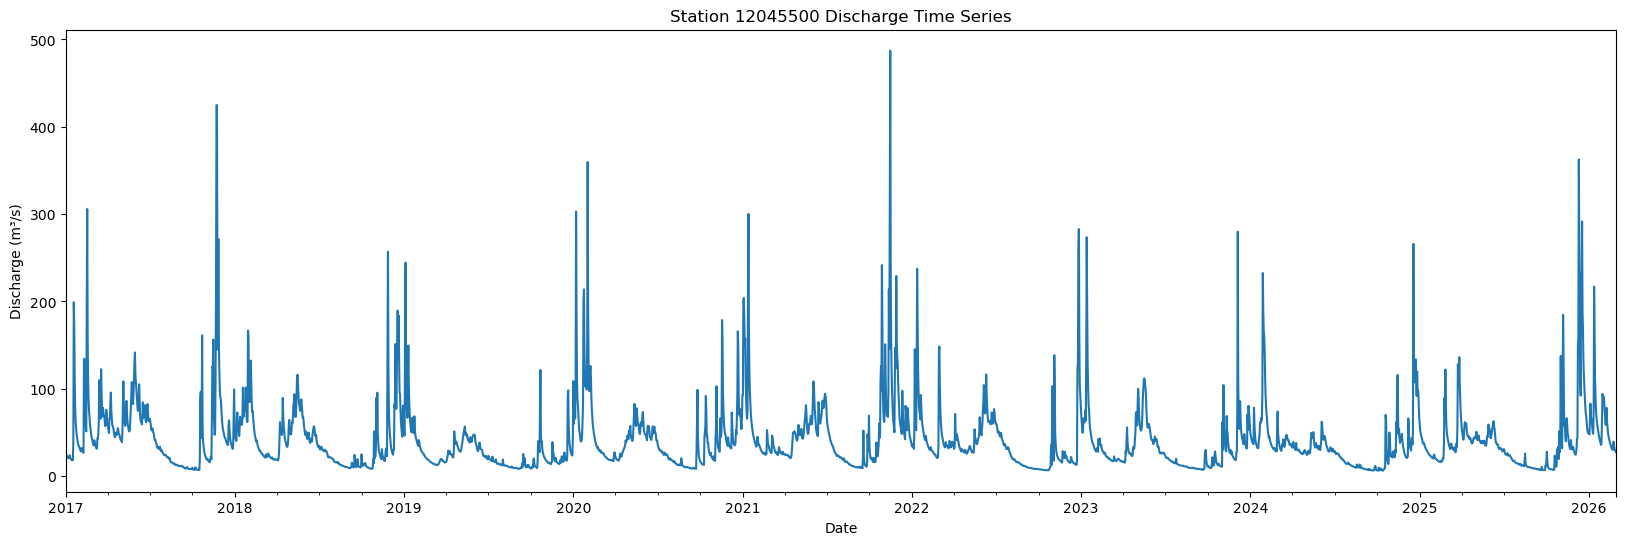

In [47]:
discharge_timeseries(elwha_df, f"Station {stations_df.loc['Elwha River', 'station_id']}")

In [48]:
# %matplotlib widget
%matplotlib inline

In [62]:
# set focus dates
high_start = '2021-10-01'
high_end = '2022-09-30'

low_start = '2022-10-01'
low_end = '2023-09-30'

med_start = '2019-10-01'
med_end = '2020-09-30'

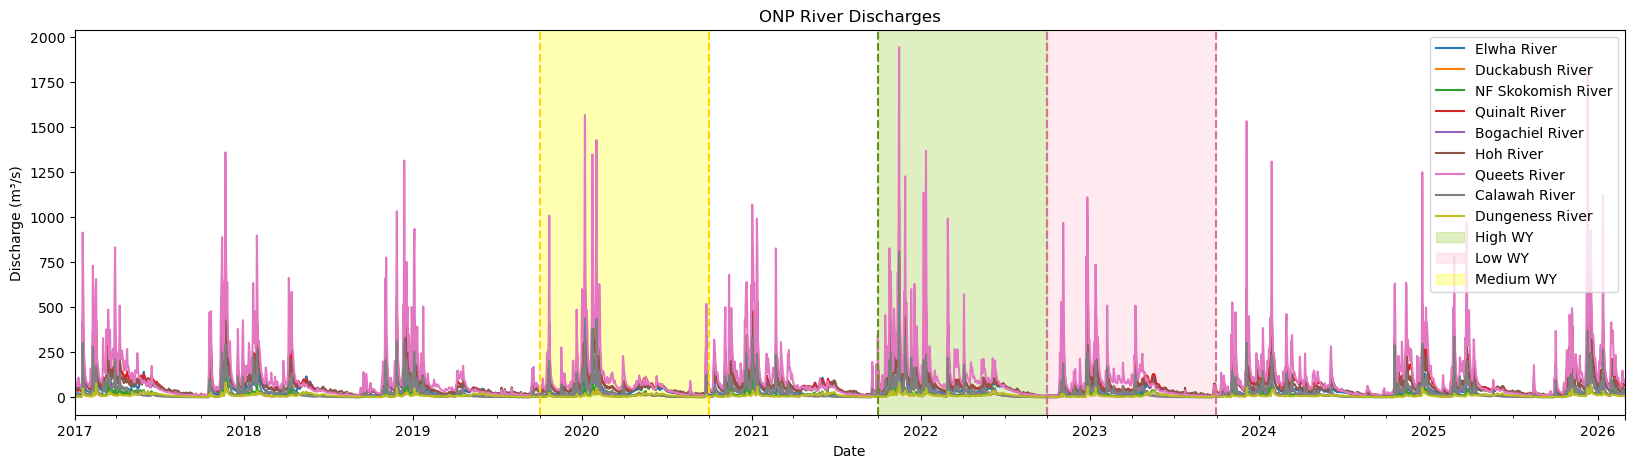

In [63]:
# plot all time series on the same plot
# use this plot to identify high and low seasons

fig, ax = plt.subplots(figsize=(20,5))
ax.set_title(f"ONP River Discharges")
ax.set_ylabel('Discharge (m³/s)')
for river in stations_df.index:
    station_id = stations_df.loc[river, 'station_id']
    df = usgs_discharge(str(station_id), start_date, end_date)
    df['Q_cms'].plot(ax=ax, label=river)  
ax.set_xlabel('Date')

# setting highlights for times of interest
ax.axvline(pd.Timestamp(high_start), color='olivedrab', linestyle='--')
ax.axvline(pd.Timestamp(high_end), color='olivedrab', linestyle='--')
ax.axvspan(pd.Timestamp(high_start), pd.Timestamp(high_end), color='yellowgreen', alpha=0.3, label='High WY')

ax.axvline(pd.Timestamp(low_start), color='palevioletred', linestyle='--')
ax.axvline(pd.Timestamp(low_end), color='palevioletred', linestyle='--')
ax.axvspan(pd.Timestamp(low_start), pd.Timestamp(low_end), color='pink', alpha=0.3, label='Low WY')

ax.axvline(pd.Timestamp(med_start), color='gold', linestyle='--')
ax.axvline(pd.Timestamp(med_end), color='gold', linestyle='--')
ax.axvspan(pd.Timestamp(med_start), pd.Timestamp(med_end), color='yellow', alpha=0.3, label='Medium WY')

ax.legend()


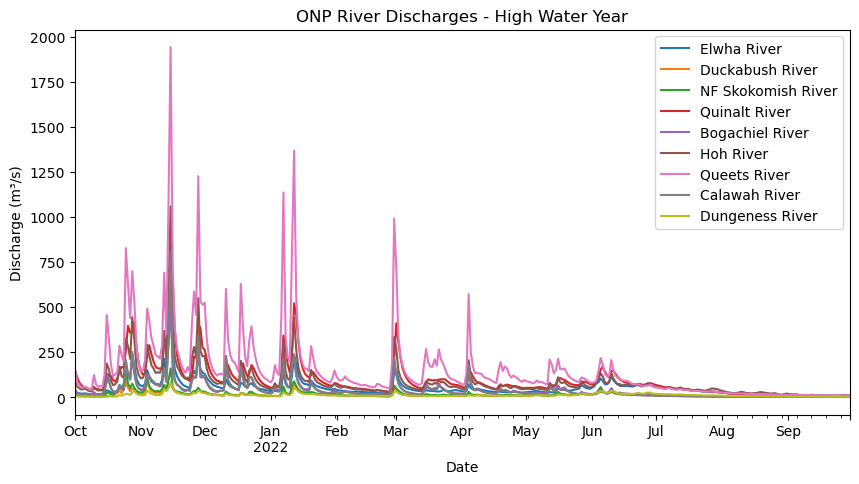

In [64]:
# generate plots for focus dates - HIGH WY
# these three could prob be generated side by side using subplots, or we could pick an example river and overlay stream flow for the three diff periods in different colors

fig, ax = plt.subplots(figsize=(10,5))
ax.set_title(f"ONP River Discharges - High Water Year")
ax.set_ylabel('Discharge (m³/s)')
for river in stations_df.index:
    station_id = stations_df.loc[river, 'station_id']
    df = usgs_discharge(str(station_id), high_start, high_end)
    df['Q_cms'].plot(ax=ax, label=river)  
ax.set_xlabel('Date')
ax.legend()

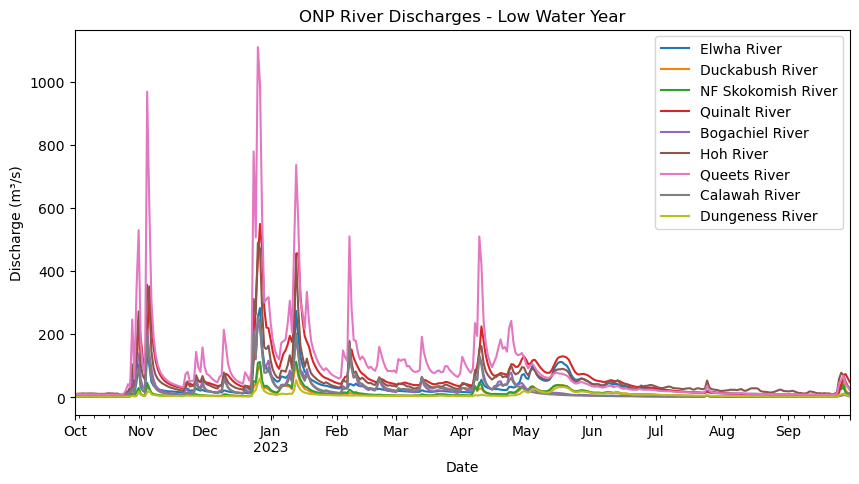

In [65]:
# generate plots for focus dates - LOW WY

fig, ax = plt.subplots(figsize=(10,5))
ax.set_title(f"ONP River Discharges - Low Water Year")
ax.set_ylabel('Discharge (m³/s)')
for river in stations_df.index:
    station_id = stations_df.loc[river, 'station_id']
    df = usgs_discharge(str(station_id), low_start, low_end)
    df['Q_cms'].plot(ax=ax, label=river)  
ax.set_xlabel('Date')
ax.legend()

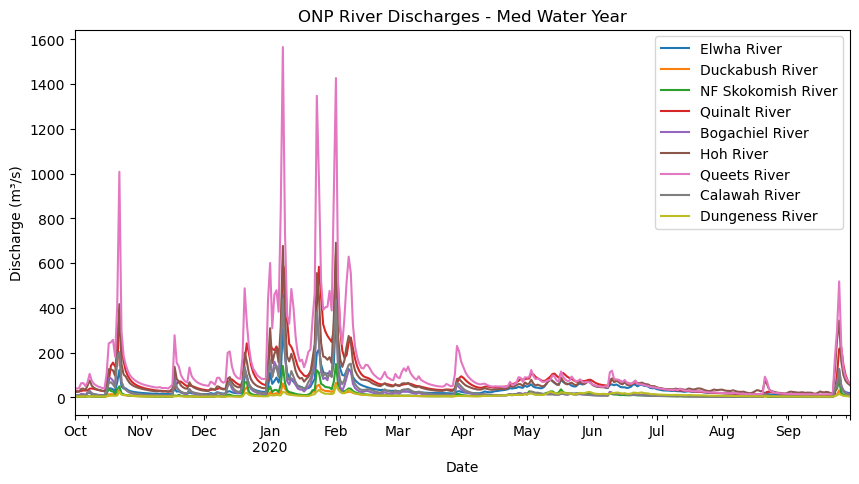

In [66]:
# generate plots for focus dates - MED WY

fig, ax = plt.subplots(figsize=(10,5))
ax.set_title(f"ONP River Discharges - Med Water Year")
ax.set_ylabel('Discharge (m³/s)')
for river in stations_df.index:
    station_id = stations_df.loc[river, 'station_id']
    df = usgs_discharge(str(station_id), med_start, med_end)
    df['Q_cms'].plot(ax=ax, label=river)  
ax.set_xlabel('Date')
ax.legend()